In [5]:
import numpy as np
from numba import njit
from matplotlib import pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from PIL import Image
from src.glcm_features.features import ( 
                                        compute_autocorrelation,      
                                        compute_cluster_prominence, 
                                        compute_cluster_shade,
                                        compute_cluster_tendency,
                                        compute_difference_average, 
                                        compute_difference_entropy,
                                        compute_difference_variance,
                                        compute_entropy,
                                        compute_information_measure_correlation_1,
                                        compute_information_measure_correlation_2,
                                        compute_maximal_correlation_coefficient,
                                        compute_inverse_difference,
                                        compute_inverse_difference_norm,
                                        compute_inverse_difference_moment,
                                        compute_inverse_difference_moment_norm,
                                        compute_inverse_variance,
                                        compute_joint_average,
                                        compute_maximum_probability,
                                        compute_maximal_correlation_coefficient,
                                        compute_sum_average,
                                        compute_sum_entropy,
                                        compute_sum_of_squares,
                                        compute_sum_variance
                                        )

In [6]:
def compute_features_plot(image_in, tile_s=8, tile_o=4, N=256):
    image_in = image_in.convert('L')
    image_in_array = np.array(image_in)
    row_size = image_in_array.shape[0]
    col_size = image_in_array.shape[1]

    tiles = []
    glcms = []

    # Initialize lists for all features
    contrast_value = []
    correlation_value = []
    homogeneity_value = []
    energy_value = []
    imc1_value = []
    autocorr_value = []
    cluster_prom_value = []
    cluster_shade_value = []
    cluster_tend_value = []
    sum_avg_value = []
    entropy_value = []
    diff_ent_value = []
    diff_var_value = []
    inv_diff_value = []
    inv_diff_norm_value = []
    inv_var_value = []
    joint_avg_value = []
    max_prob_value = []
    sum_ent_value = []
    sum_squares_value = []

    for r in range(0, row_size - tile_s + 1, tile_o):
        for c in range(0, col_size - tile_s + 1, tile_o):
            tile = image_in_array[r:r+tile_s, c:c+tile_s]
            tiles.append(tile)
            distances = [1]

            glcm0 = graycomatrix(tile, distances=distances, angles=[0], levels=N, symmetric=True)
            glcm1 = graycomatrix(tile, distances=distances, angles=[np.pi/4], levels=N, symmetric=True)
            glcm2 = graycomatrix(tile, distances=distances, angles=[np.pi/2], levels=N, symmetric=True)
            glcm3 = graycomatrix(tile, distances=distances, angles=[3 * np.pi/4], levels=N, symmetric=True)
            
            mean_glcm = (np.squeeze(glcm0) + np.squeeze(glcm1) + np.squeeze(glcm2) + np.squeeze(glcm3)) / 4
            glcm = mean_glcm / np.sum(mean_glcm)

            glcms.append(glcm)

            glcm_4d =(glcm0 + glcm1 + glcm2 + glcm3) / 4
            glcm_4d = glcm_4d / np.sum(mean_glcm)

            contrast_value.append(float(graycoprops(glcm_4d, 'contrast')))
            correlation_value.append(float(graycoprops(glcm_4d, 'correlation')))
            homogeneity_value.append(float(graycoprops(glcm_4d, 'homogeneity')))
            energy_value.append(float(graycoprops(glcm_4d, 'energy')))
            imc1_value.append(float(compute_information_measure_correlation_1(glcm)))
            autocorr_value.append(float(compute_autocorrelation(glcm)))
            cluster_prom_value.append(float(compute_cluster_prominence(glcm)))
            cluster_shade_value.append(float(compute_cluster_shade(glcm)))
            cluster_tend_value.append(float(compute_cluster_tendency(glcm)))
            sum_avg_value.append(float(compute_sum_average(glcm)))
            entropy_value.append(float(compute_entropy(glcm)))
            diff_ent_value.append(float(compute_difference_entropy(glcm)))
            diff_var_value.append(float(compute_difference_variance(glcm)))
            inv_diff_value.append(float(compute_inverse_difference(glcm)))
            inv_diff_norm_value.append(float(compute_inverse_difference_norm(glcm)))
            inv_var_value.append(float(compute_inverse_variance(glcm)))
            joint_avg_value.append(float(compute_joint_average(glcm)))
            max_prob_value.append(float(compute_maximum_probability(glcm)))
            sum_ent_value.append(float(compute_sum_entropy(glcm)))
            sum_squares_value.append(float(compute_sum_of_squares(glcm)))
            

    def normalize_feature(values):
        val_max = max(values)
        val_min = min(values)
        if val_max - val_min == 0:
            return [0.5] * len(values), val_min, val_max
        return [(val - val_min) / (val_max - val_min) for val in values], val_min, val_max
    
    contrast_values, contrast_min, contrast_max = normalize_feature(contrast_value)
    correlation_values, correlation_min, correlation_max = normalize_feature(correlation_value)
    homogeneity_values, homogeneity_min, homogeneity_max = normalize_feature(homogeneity_value)
    energy_values, energy_min, energy_max = normalize_feature(energy_value)
    imc1_values, imc1_min, imc1_max = normalize_feature(imc1_value)
    autocorr_values, autocorr_min, autocorr_max = normalize_feature(autocorr_value)
    cluster_prom_values, cluster_prom_min, cluster_prom_max = normalize_feature(cluster_prom_value)
    cluster_shade_values, cluster_shade_min, cluster_shade_max = normalize_feature(cluster_shade_value)
    cluster_tend_values, cluster_tend_min, cluster_tend_max = normalize_feature(cluster_tend_value)
    sum_avg_values, sum_avg_min, sum_avg_max = normalize_feature(sum_avg_value)
    entropy_values, entropy_min, entropy_max = normalize_feature(entropy_value)
    diff_ent_values, diff_ent_min, diff_ent_max = normalize_feature(diff_ent_value)
    diff_var_values, diff_var_min, diff_var_max = normalize_feature(diff_var_value)
    inv_diff_values, inv_diff_min, inv_diff_max = normalize_feature(inv_diff_value)
    inv_diff_norm_values, inv_diff_norm_min, inv_diff_norm_max = normalize_feature(inv_diff_norm_value)
    inv_var_values, inv_var_min, inv_var_max = normalize_feature(inv_var_value)
    joint_avg_values, joint_avg_min, joint_avg_max = normalize_feature(joint_avg_value)
    max_prob_values, max_prob_min, max_prob_max = normalize_feature(max_prob_value)
    sum_ent_values, sum_ent_min, sum_ent_max = normalize_feature(sum_ent_value)
    sum_squares_values, sum_squares_min, sum_squares_max = normalize_feature(sum_squares_value)
    

    # Reshape features into arrays
    shape = (int(2*(row_size/tile_s) - 1), int(2*(col_size/tile_s) - 1))
    
    contrast_array = np.reshape(contrast_values, shape)
    correlation_array = np.reshape(correlation_values, shape)
    homogeneity_array = np.reshape(homogeneity_values, shape)
    energy_array = np.reshape(energy_values, shape)
    imc1_array = np.reshape(imc1_values, shape)
    autocorr_array = np.reshape(autocorr_values, shape)
    cluster_prom_array = np.reshape(cluster_prom_values, shape)
    cluster_shade_array = np.reshape(cluster_shade_values, shape)
    cluster_tend_array = np.reshape(cluster_tend_values, shape)
    sum_avg_array = np.reshape(sum_avg_values, shape)
    entropy_array = np.reshape(entropy_values, shape)
    diff_ent_array = np.reshape(diff_ent_values, shape)
    diff_var_array = np.reshape(diff_var_values, shape)
    inv_diff_array = np.reshape(inv_diff_values, shape)
    inv_diff_norm_array = np.reshape(inv_diff_norm_values, shape)
    inv_var_array = np.reshape(inv_var_values, shape)
    joint_avg_array = np.reshape(joint_avg_values, shape)
    max_prob_array = np.reshape(max_prob_values, shape)
    sum_ent_array = np.reshape(sum_ent_values, shape)
    sum_squares_array = np.reshape(sum_squares_values, shape)


    fig, ax = plt.subplots(11, 2, figsize=(10, 20))

    # Original Image
    original = ax[0, 0].imshow(image_in_array, cmap='gray')
    ax[0, 0].axis('off')
    ax[0, 0].set_title("Original Image")
    fig.colorbar(original, ax=ax[0, 0])

    # Contrast
    contrast_img = ax[0, 1].imshow(contrast_array, cmap='Reds')
    ax[0, 1].axis('off')
    ax[0, 1].set_title("Contrast")
    cbar = fig.colorbar(contrast_img, ax=ax[0, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(contrast_min, 4), round(contrast_max, 4)])

    # Homogeneity
    homogeneity_img = ax[1, 0].imshow(homogeneity_array, cmap='Reds')
    ax[1, 0].axis('off')
    ax[1, 0].set_title("Homogeneity")
    cbar = fig.colorbar(homogeneity_img, ax=ax[1, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(homogeneity_min, 4), round(homogeneity_max, 4)])

    # Correlation
    correlation_img = ax[1, 1].imshow(correlation_array, cmap='Reds')
    ax[1, 1].axis('off')
    ax[1, 1].set_title("Correlation")
    cbar = fig.colorbar(correlation_img, ax=ax[1, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(correlation_min, 4), round(correlation_max, 4)])

    # Energy
    energy_img = ax[2, 0].imshow(energy_array, cmap='Reds')
    ax[2, 0].axis('off')
    ax[2, 0].set_title("Energy")
    cbar = fig.colorbar(energy_img, ax=ax[2, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(energy_min, 4), round(energy_max, 4)])

    # IMC1
    imc1_img = ax[2, 1].imshow(imc1_array, cmap='Reds')
    ax[2, 1].axis('off')
    ax[2, 1].set_title("IMC1")
    cbar = fig.colorbar(imc1_img, ax=ax[2, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(imc1_min, 4), round(imc1_max, 4)])

    # Autocorrelation
    autocorr_img = ax[3, 0].imshow(autocorr_array, cmap='Reds')
    ax[3, 0].axis('off')
    ax[3, 0].set_title("Autocorrelation")
    cbar = fig.colorbar(autocorr_img, ax=ax[3, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(autocorr_min, 4), round(autocorr_max, 4)])

    # Cluster prominence
    cluster_prom_img = ax[3, 1].imshow(cluster_prom_array, cmap='Reds')
    ax[3, 1].axis('off')
    ax[3, 1].set_title("Cluster prominence")
    cbar = fig.colorbar(cluster_prom_img, ax=ax[3, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(cluster_prom_min, 4), round(cluster_prom_max, 4)])

    # Cluster shade
    cluster_shade_img = ax[4, 0].imshow(cluster_shade_array, cmap='Reds')
    ax[4, 0].axis('off')
    ax[4, 0].set_title("Cluster shade")
    cbar = fig.colorbar(cluster_shade_img, ax=ax[4, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(cluster_shade_min, 4), round(cluster_shade_max, 4)])

    # Cluster tendency
    cluster_tend_img = ax[4, 1].imshow(cluster_tend_array, cmap='Reds')
    ax[4, 1].axis('off')
    ax[4, 1].set_title("Cluster tendency")
    cbar = fig.colorbar(cluster_tend_img, ax=ax[4, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(cluster_tend_min, 4), round(cluster_tend_max, 4)])

    # Sum average
    sum_avg_img = ax[5, 0].imshow(sum_avg_array, cmap='Reds')
    ax[5, 0].axis('off')
    ax[5, 0].set_title("Sum avergae")
    cbar = fig.colorbar(sum_avg_img, ax=ax[5, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(sum_avg_min, 4), round(sum_avg_max, 4)])

    # Entropy
    entropy_img = ax[5, 1].imshow(entropy_array, cmap='Reds')
    ax[5, 1].axis('off')
    ax[5, 1].set_title("Entropy")
    cbar = fig.colorbar(entropy_img, ax=ax[5, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(entropy_min, 4), round(entropy_max, 4)])

    # Difference entopry
    diff_ent_img = ax[6, 0].imshow(diff_ent_array, cmap='Reds')
    ax[6, 0].axis('off')
    ax[6, 0].set_title("Difference entopry")
    cbar = fig.colorbar(diff_ent_img, ax=ax[6, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(diff_ent_min, 4), round(diff_ent_max, 4)])

    # Difference variance
    diff_var_img = ax[6, 1].imshow(diff_var_array, cmap='Reds')
    ax[6, 1].axis('off')
    ax[6, 1].set_title("Difference variance")
    cbar = fig.colorbar(diff_var_img, ax=ax[6, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(diff_var_min, 4), round(diff_var_max, 4)])

    # Inverse difference
    inv_diff_img = ax[7, 0].imshow(inv_diff_array, cmap='Reds')
    ax[7, 0].axis('off')
    ax[7, 0].set_title("Inverse difference")
    cbar = fig.colorbar(inv_diff_img, ax=ax[7, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(inv_diff_min, 4), round(inv_diff_max, 4)])

    # Inverse difference normalized
    inv_diff_norm_img = ax[7, 1].imshow(inv_diff_norm_array, cmap='Reds')
    ax[7, 1].axis('off')
    ax[7, 1].set_title("Inverse difference normalized")
    cbar = fig.colorbar(inv_diff_norm_img, ax=ax[7, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(inv_diff_norm_min, 4), round(inv_diff_norm_max, 4)])

    # Inverse variance
    inv_var_img = ax[8, 0].imshow(inv_var_array, cmap='Reds')
    ax[8, 0].axis('off')
    ax[8, 0].set_title("Inverse variance")
    cbar = fig.colorbar(inv_var_img, ax=ax[8, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(inv_var_min, 4), round(inv_var_max, 4)])

    # Joint average
    joint_avg_img = ax[8, 1].imshow(joint_avg_array, cmap='Reds')
    ax[8, 1].axis('off')
    ax[8, 1].set_title("Joint average")
    cbar = fig.colorbar(joint_avg_img, ax=ax[8, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(joint_avg_min, 4), round(joint_avg_max, 4)])

    # Max prob
    max_prob_img = ax[9, 0].imshow(max_prob_array, cmap='Reds')
    ax[9, 0].axis('off')
    ax[9, 0].set_title("Maximum probability")
    cbar = fig.colorbar(max_prob_img, ax=ax[9, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(max_prob_min, 4), round(max_prob_max, 4)])

    # MCC
    # sum_avg2_img = ax[9, 1].imshow(sum_avg2_array, cmap='Reds')
    # ax[9, 1].axis('off')
    # ax[9, 1].set_title("Sum average (2)")
    # cbar = fig.colorbar(sum_avg2_img, ax=ax[9, 1])
    # cbar.set_ticks(ticks=[0, 1], labels=[round(sum_avg2_min, 4), round(sum_avg2_max, 4)])

    # Sum entropy
    sum_ent_img = ax[10, 0].imshow(sum_ent_array, cmap='Reds')
    ax[10, 0].axis('off')
    ax[10, 0].set_title("Sum entropy")
    cbar = fig.colorbar(sum_ent_img, ax=ax[10, 0])
    cbar.set_ticks(ticks=[0, 1], labels=[round(sum_ent_min, 4), round(sum_ent_max, 4)])

    # Sum of squares
    sum_squares_img = ax[10, 1].imshow(sum_squares_array, cmap='Reds')
    ax[10, 1].axis('off')
    ax[10, 1].set_title("Sum of squares")
    cbar = fig.colorbar(sum_squares_img, ax=ax[10, 1])
    cbar.set_ticks(ticks=[0, 1], labels=[round(sum_squares_min, 4), round(sum_squares_max, 4)])


    plt.tight_layout()
    plt.show()
            

/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast_value.append(float(graycoprops(glcm_4d, 'contrast')))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  correlation_value.append(float(graycoprops(glcm_4d, 'correlation')))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before perf

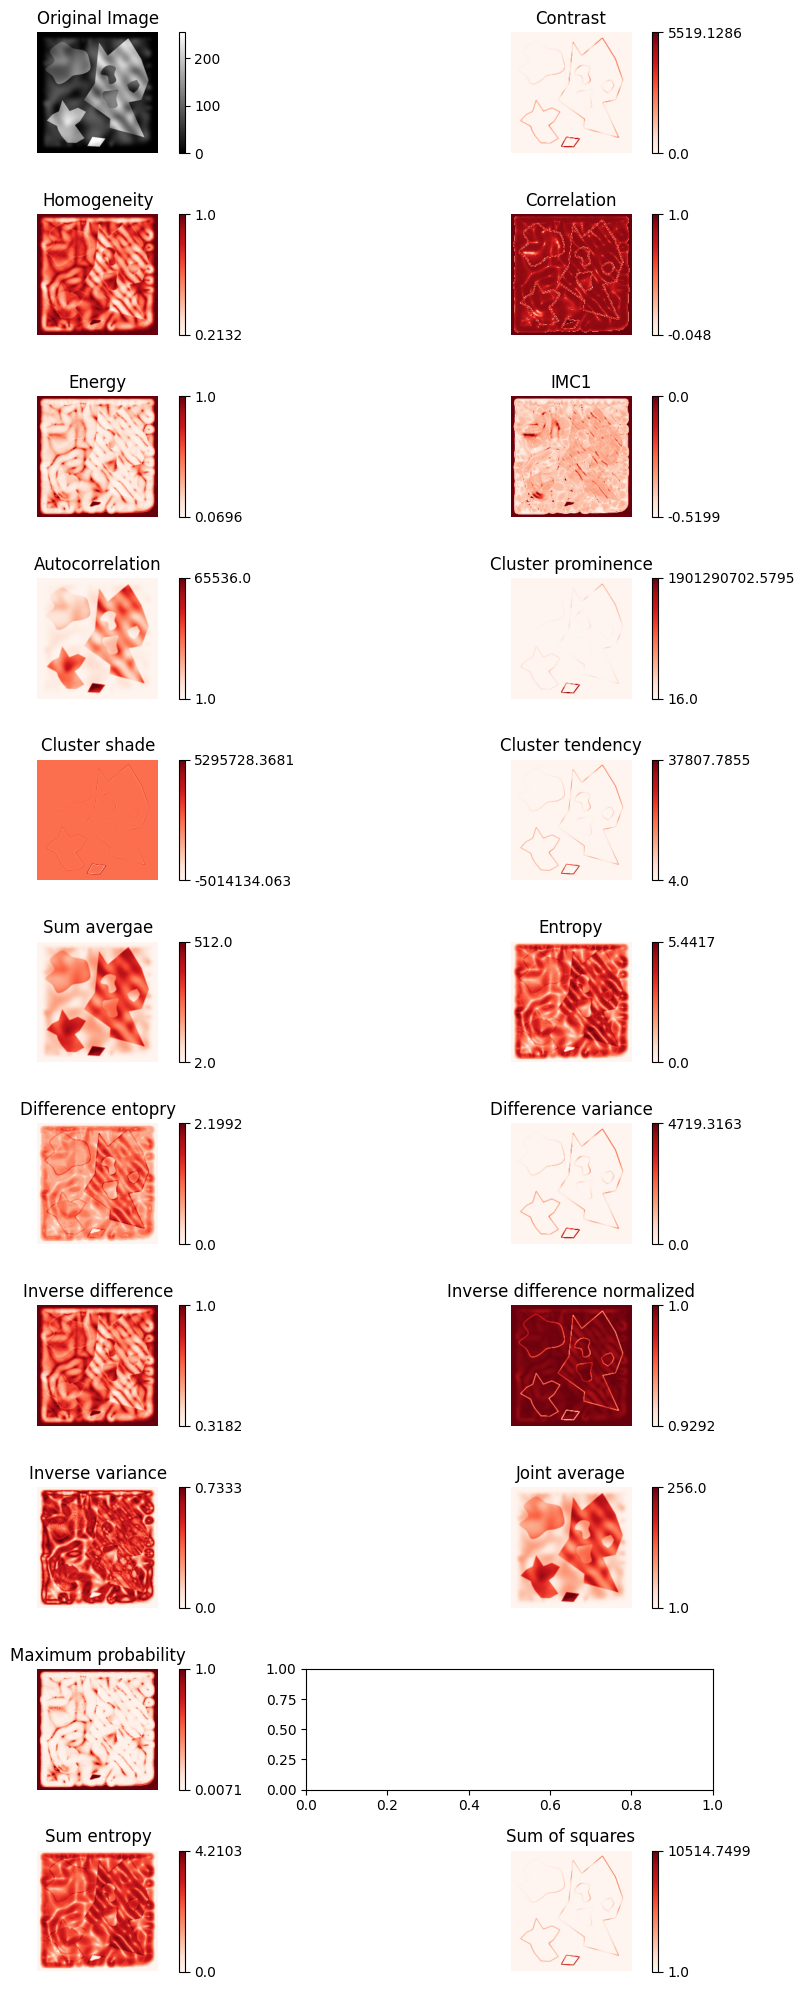

In [7]:
gs_image =Image.open('src/edgeEvalSimple.png')
compute_features_plot(gs_image)

/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  contrast_value.append(float(graycoprops(glcm_4d, 'contrast')))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  correlation_value.append(float(graycoprops(glcm_4d, 'correlation')))
/var/folders/v4/ll98xkld14g9tg5r1jjcr5j80000gn/T/ipykernel_83602/3389231842.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before perf

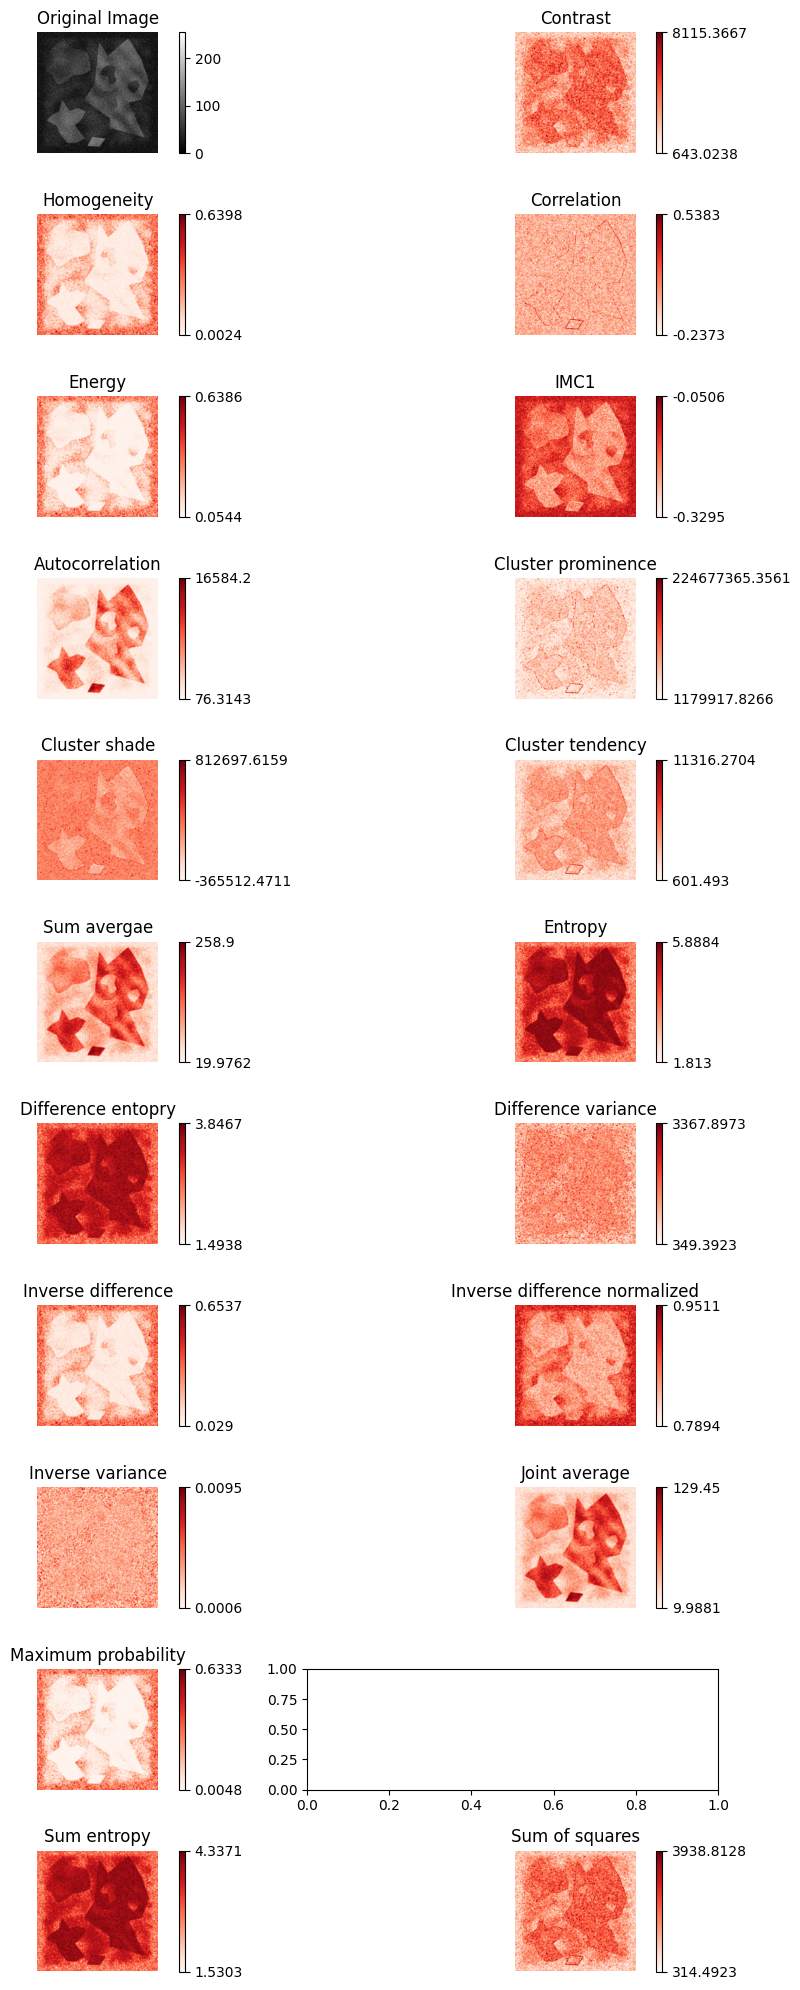

In [9]:
gs_image =Image.open('src/edgeEvalSimple_gauss_100_poiss_0-1.png')
compute_features_plot(gs_image)